# 🌾 Rice Leaf Disease Classification

## Business Case
Build a CNN model to classify 3 major rice leaf diseases:
- **Bacterial Leaf Blight**
- **Brown Spot**
- **Leaf Smut**

Dataset: 120 images (40 per class), RGB, resized to 224×224.

## 1. Install Dependencies

In [15]:
pip install tensorboard

   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/5.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/5.5 MB ? eta -:--:--
   --- ------------------------------------ 0.5/5.5 MB 872.9 kB/s eta 0:00:06
   --- ------------------------------------ 0.5/5.5 MB 872.9 kB/s eta 0:00:06
   ----- ---------------------------------- 0.8/5.5 MB 743.0 kB/s eta 0:00:07
   ------- -------------------------------- 1.0/5.5 MB 775.9 kB/s eta 0:00:06
   ------- -------------------------------- 1.0/5.5 MB 775.9 kB/s eta 0:00:06
   ------- -------------------------------- 1.0/5.5 MB 775.9 kB/s eta 0:00:06
   --------- ------------------------------ 1.3/5.5 MB 686.8 kB/s eta 0:00:07
   --------- ------------------------------ 1.3/5.5 MB 686.8 kB/s eta 0:00:07
   ----------- ---------------------------- 1.6/5.5 MB 670.3 kB/s eta 0:00:06
   ----------- -------

In [12]:
pip install keras-tuner


   -------------------- ------------------- 1/2 [keras-tuner]
   ---------------------------------------- 2/2 [keras-tuner]

Note: you may need to restart the kernel to use updated packages.


In [1]:
# Run this cell once to install all required packages
import subprocess, sys

packages = [
    'tensorflow==2.13.0',
    'keras-tuner',
    'matplotlib',
    'seaborn',
    'numpy',
    'pandas',
    'scikit-learn',
    'Pillow'
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('✅ All packages installed successfully!')

CalledProcessError: Command '['C:\\Users\\Asus\\anaconda3\\python.exe', '-m', 'pip', 'install', 'tensorflow==2.13.0', '-q']' returned non-zero exit status 1.

## 2. Import Libraries

In [2]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

# Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'✅ TensorFlow version: {tf.__version__}')
print(f'✅ Keras version: {keras.__version__}')
print(f'✅ GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

✅ TensorFlow version: 2.21.0
✅ Keras version: 3.14.0
✅ GPU available: False


## 3. Configuration

In [3]:
# ─── CHANGE THIS PATH to your dataset folder ───────────────────────────────
# The folder must have sub-folders named after each class:
#   RiceLeaf/
#       Bacterial leaf blight/
#       Brown spot/
#       Leaf smut/
DATA_DIR = r'rice_leaf_diseases'   # <-- update this path
# ────────────────────────────────────────────────────────────────────────────

IMG_HEIGHT, IMG_WIDTH = 224, 224
INPUT_SHAPE = (224, 224, 3)
BATCH_SIZE = 32
EPOCHS = 30
NUM_CLASSES = 3
CLASS_NAMES = ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']
MODELS_DIR = 'saved_models'
os.makedirs(MODELS_DIR, exist_ok=True)

print('✅ Configuration set')

✅ Configuration set


## 4. Load Dataset

In [4]:
# Verify the dataset path exists
if not os.path.exists(DATA_DIR):
    raise FileNotFoundError(
        f'Dataset not found at: {DATA_DIR}\n'
        'Please update DATA_DIR in the Configuration cell.'
    )

# Load all images using Keras utility
data_ds = tf.keras.utils.image_dataset_from_directory(
    directory=DATA_DIR,
    labels='inferred',
    label_mode='int',
    class_names=None,
    color_mode='rgb',
    batch_size=None,           # load one image at a time
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    seed=SEED,
    shuffle=True
)

class_names = data_ds.class_names
print(f'✅ Classes found: {class_names}')
print(f'✅ Total images : {len(data_ds)}')

Found 120 files belonging to 3 classes.
✅ Classes found: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']
✅ Total images : 120


## 5. Visualise Sample Images

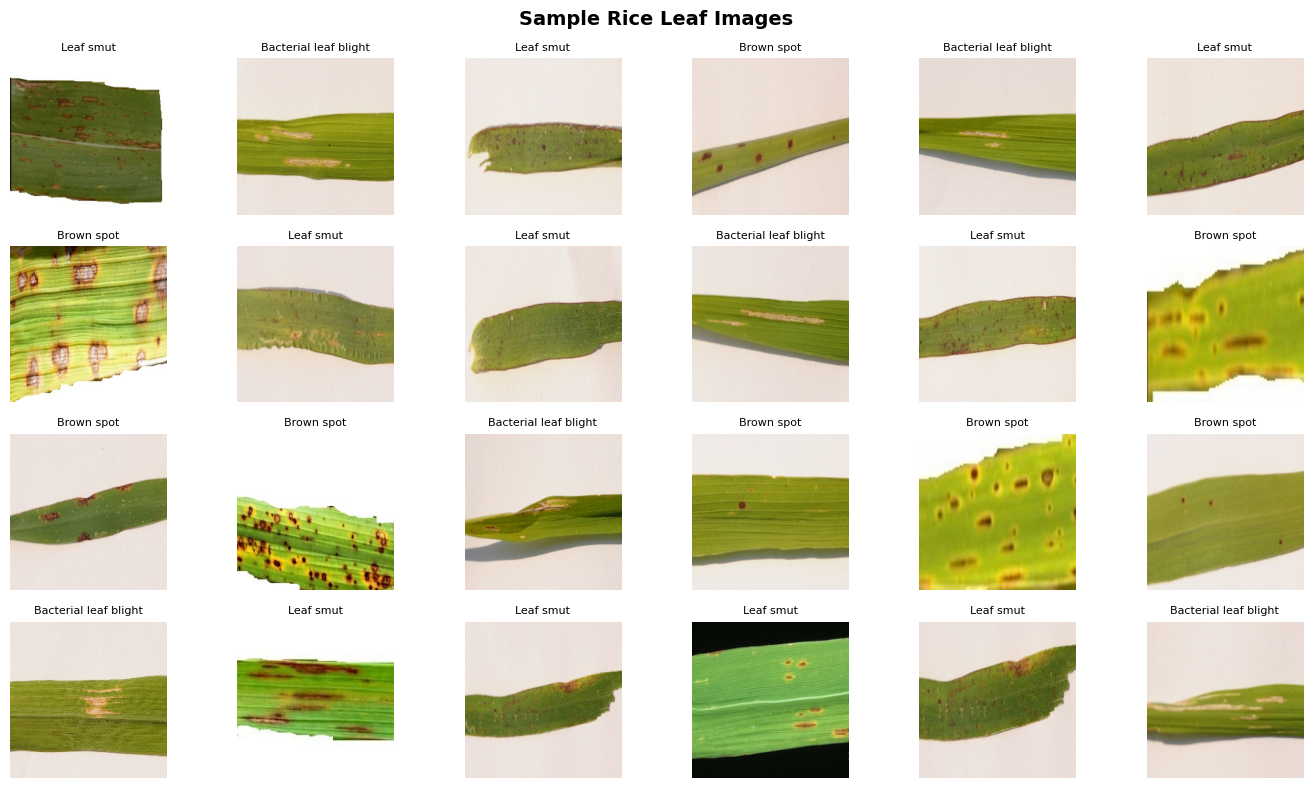

In [5]:
def show_images(dataset, class_names, n_rows=4, n_cols=6):
    """Display a grid of images with their class labels."""
    images, labels = [], []
    for img, lbl in dataset.take(n_rows * n_cols):
        images.append(img.numpy().astype('uint8'))
        labels.append(lbl.numpy())

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 8))
    for ax, img, lbl in zip(axes.flatten(), images, labels):
        ax.imshow(img)
        ax.set_title(class_names[lbl], fontsize=8)
        ax.axis('off')
    plt.suptitle('Sample Rice Leaf Images', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_images(data_ds, class_names)

## 6. Preprocess — Extract Arrays, Split, Normalise, Encode

In [6]:
# Collect all images and labels into numpy arrays
X, y = [], []
for img, label in data_ds:
    X.append(img.numpy())
    y.append(label.numpy())

X = np.array(X, dtype='float32')
y = np.array(y, dtype='int32')

print(f'X shape: {X.shape} | y shape: {y.shape}')

# Class distribution
unique, counts = np.unique(y, return_counts=True)
print('Class distribution:')
for u, c in zip(unique, counts):
    print(f'  {class_names[u]}: {c} images')

X shape: (120, 224, 224, 3) | y shape: (120,)
Class distribution:
  Bacterial leaf blight: 40 images
  Brown spot: 40 images
  Leaf smut: 40 images


In [7]:
# Train / test split  (80 train : 40 test  for 120-image dataset)
TRAIN_SIZE = 80
X_train, X_test = X[:TRAIN_SIZE], X[TRAIN_SIZE:]
y_train, y_test = y[:TRAIN_SIZE], y[TRAIN_SIZE:]

# Normalise pixel values to [0, 1]
X_train = X_train / 255.0
X_test  = X_test  / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  num_classes=NUM_CLASSES)

print(f'X_train: {X_train.shape}  y_train: {y_train_cat.shape}')
print(f'X_test : {X_test.shape}   y_test : {y_test_cat.shape}')

X_train: (80, 224, 224, 3)  y_train: (80, 3)
X_test : (40, 224, 224, 3)   y_test : (40, 3)


## 7. Model 1 — Baseline CNN

In [8]:
def build_baseline_cnn(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):
    model = Sequential([
        Conv2D(16, (3,3), padding='same', activation='relu', use_bias=False,
               input_shape=input_shape),
        MaxPooling2D(pool_size=3),

        Conv2D(32, (3,3), padding='same', activation='relu', use_bias=False),
        MaxPooling2D(pool_size=3),

        Conv2D(64, (3,3), padding='same', activation='relu', use_bias=False),
        MaxPooling2D(pool_size=3),

        Conv2D(128, (3,3), padding='same', activation='relu', use_bias=False),
        MaxPooling2D(pool_size=2),

        Conv2D(256, (3,3), padding='same', activation='relu', use_bias=False),
        MaxPooling2D(pool_size=2),

        Dropout(0.3),
        Flatten(),
        Dropout(0.5),
        Dense(250, activation='relu'),
        Dense(100, activation='relu'),
        Dense(num_classes, activation='softmax')
    ], name='Baseline_CNN')
    return model

model1 = build_baseline_cnn()
model1.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 16)        │             432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 74, 74, 32)          │           4,608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 24, 24, 64)          │          18,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 8, 8, 128)           │          73,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 4, 4, 256)           │         294,912 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 2, 2, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 2, 2, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 250)                 │         256,250 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100)                 │          25,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │             303 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 673,765 (2.57 MB)

 Trainable params: 673,765 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model1.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

cb_checkpoint = ModelCheckpoint(
    filepath=os.path.join(MODELS_DIR, 'baseline_best.keras'),
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)
cb_early = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)

history1 = model1.fit(
    X_train, y_train_cat,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_test, y_test_cat),
    callbacks=[cb_checkpoint, cb_early],
    shuffle=True,
    verbose=1
)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.2354 - loss: 1.1081 
Epoch 1: val_accuracy improved from None to 0.27500, saving model to saved_models\baseline_best.keras

Epoch 1: finished saving model to saved_models\baseline_best.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 452ms/step - accuracy: 0.2375 - loss: 1.1101 - val_accuracy: 0.2750 - val_loss: 1.1141
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.3177 - loss: 1.1078 
Epoch 2: val_accuracy did not improve from 0.27500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 201ms/step - accuracy: 0.3125 - loss: 1.1082 - val_accuracy: 0.2500 - val_loss: 1.1099
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.2458 - loss: 1.1088 
Epoch 3: val_accuracy did not improve from 0.27500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step - accuracy: 0.2375 - loss: 1.1099 - val_accuracy: 0.2750 - val_loss: 1.1015
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.3542 - loss: 1.0871 
Epoch 4: val_accuracy did not improve from 0.27

## 8. Model 2 — CNN + Data Augmentation

In [10]:
datagen = ImageDataGenerator(
    shear_range=0.3,
    zoom_range=0.3,
    width_shift_range=0.4,
    height_shift_range=0.4,
    fill_mode='nearest',
    horizontal_flip=True,
    vertical_flip=True
)
datagen.fit(X_train)

model2 = build_baseline_cnn()
model2._name = 'Augmented_CNN'
model2.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

cb_checkpoint2 = ModelCheckpoint(
    filepath=os.path.join(MODELS_DIR, 'augmented_best.keras'),
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)
cb_early2 = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)

steps = max(1, len(X_train) // BATCH_SIZE)
history2 = model2.fit(
    datagen.flow(X_train, y_train_cat, batch_size=BATCH_SIZE),
    validation_data=(X_test, y_test_cat),
    steps_per_epoch=steps,
    epochs=EPOCHS,
    callbacks=[cb_checkpoint2, cb_early2],
    shuffle=True,
    verbose=1
)

Epoch 1/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.3438 - loss: 1.1020
Epoch 1: val_accuracy improved from None to 0.35000, saving model to saved_models\augmented_best.keras

Epoch 1: finished saving model to saved_models\augmented_best.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.3125 - loss: 1.1065 - val_accuracy: 0.3500 - val_loss: 1.1003
Epoch 2/30
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.2500 - loss: 1.1033
Epoch 2: val_accuracy did not improve from 0.35000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.2500 - loss: 1.1033 - val_accuracy: 0.2750 - val_loss: 1.1020
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.5156 - loss: 1.0912
Epoch 3: val_accuracy did not improve from 0.35000
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 316ms/step - accuracy: 0.5000 - loss: 1.0907 - val_accuracy: 0.2750 - val_loss: 1.1173
Epoch 4/30
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.2500 - loss: 1.1147
Epoch 4: val_accuracy did not improve from 0.350

## 9. Model 3 — Keras Tuner Hyperparameter Search

In [16]:
import keras_tuner as kt

def build_tunable_model(hp):
    m = Sequential()

    # Conv block 1
    m.add(Conv2D(
        filters=hp.Int('c1_filters', 8, 32, step=8),
        kernel_size=hp.Choice('c1_kernel', [2, 3]),
        padding=hp.Choice('c1_pad', ['same', 'valid']),
        activation='relu',
        input_shape=INPUT_SHAPE
    ))
    m.add(MaxPooling2D())

    # Conv block 2
    m.add(Conv2D(
        filters=hp.Int('c2_filters', 16, 64, step=16),
        kernel_size=hp.Choice('c2_kernel', [2, 3]),
        padding=hp.Choice('c2_pad', ['same', 'valid']),
        activation='relu'
    ))
    m.add(MaxPooling2D())

    # Conv block 3
    m.add(Conv2D(
        filters=hp.Int('c3_filters', 32, 64, step=16),
        kernel_size=hp.Choice('c3_kernel', [2, 3]),
        padding=hp.Choice('c3_pad', ['same', 'valid']),
        activation='relu'
    ))
    m.add(MaxPooling2D())

    m.add(Flatten())
    m.add(Dropout(0.3))
    m.add(Dense(
        units=hp.Int('dense_units', 50, 250, step=50),
        activation='relu'
    ))
    m.add(Dense(NUM_CLASSES, activation='softmax'))

    m.compile(
        optimizer=keras.optimizers.Adam(
            hp.Choice('lr', [1e-2, 1e-3, 1e-4])
        ),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return m


tuner = kt.RandomSearch(
    build_tunable_model,
    objective='val_accuracy',
    max_trials=3,
    directory='kt_output',
    project_name='RiceLeafDisease',
    seed=SEED,
    overwrite=True
)

tuner.search(
    datagen.flow(X_train, y_train_cat, batch_size=BATCH_SIZE),
    validation_data=(X_test, y_test_cat),
    steps_per_epoch=steps,
    epochs=10
)

print('\n✅ Tuner search complete')
tuner.results_summary(num_trials=3)

Trial 3 Complete [00h 00m 14s]
val_accuracy: 0.5249999761581421

Best val_accuracy So Far: 0.574999988079071
Total elapsed time: 00h 00m 40s

✅ Tuner search complete
Results summary
Results in kt_output\RiceLeafDisease
Showing 3 best trials
Objective(name="val_accuracy", direction="max")

Trial 1 summary
Hyperparameters:
c1_filters: 24
c1_kernel: 3
c1_pad: same
c2_filters: 64
c2_kernel: 2
c2_pad: valid
c3_filters: 32
c3_kernel: 2
c3_pad: same
dense_units: 250
lr: 0.001
Score: 0.574999988079071

Trial 2 summary
Hyperparameters:
c1_filters: 16
c1_kernel: 2
c1_pad: same
c2_filters: 16
c2_kernel: 3
c2_pad: valid
c3_filters: 64
c3_kernel: 2
c3_pad: same
dense_units: 100
lr: 0.0001
Score: 0.5249999761581421

Trial 0 summary
Hyperparameters:
c1_filters: 24
c1_kernel: 2
c1_pad: same
c2_filters: 32
c2_kernel: 3
c2_pad: same
c3_filters: 48
c3_kernel: 2
c3_pad: same
dense_units: 100
lr: 0.0001
Score: 0.4749999940395355


In [17]:
# Fine-tune the best model found by the tuner
model3 = tuner.get_best_models(num_models=1)[0]
model3.build(input_shape=(None,) + INPUT_SHAPE)
model3.summary()

cb_checkpoint3 = ModelCheckpoint(
    filepath=os.path.join(MODELS_DIR, 'tuned_best.keras'),
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)
cb_early3 = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)

history3 = model3.fit(
    datagen.flow(X_train, y_train_cat, batch_size=BATCH_SIZE),
    validation_data=(X_test, y_test_cat),
    steps_per_epoch=steps,
    initial_epoch=10,
    epochs=EPOCHS,
    callbacks=[cb_checkpoint3, cb_early3],
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 24)        │             672 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 24)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 111, 111, 64)        │           6,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 55, 55, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 55, 55, 32)          │           8,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 27, 27, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 23328)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 23328)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 250)                 │       5,832,250 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             753 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,848,107 (22.31 MB)

 Trainable params: 5,848,107 (22.31 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 11/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 598ms/step - accuracy: 0.3229 - loss: 1.5292
Epoch 11: val_accuracy improved from None to 0.40000, saving model to saved_models\tuned_best.keras

Epoch 11: finished saving model to saved_models\tuned_best.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.3333 - loss: 1.8544 - val_accuracy: 0.4000 - val_loss: 1.2758
Epoch 12/30
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.4062 - loss: 1.1969
Epoch 12: val_accuracy did not improve from 0.40000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.4062 - loss: 1.1969 - val_accuracy: 0.3250 - val_loss: 1.0716
Epoch 13/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 668ms/step - accuracy: 0.2708 - loss: 1.1521
Epoch 13: val_accuracy improved from 0.40000 to 0.55000, saving model to saved_models\tuned_best.keras

Epoch 13: finished saving model to saved_models\tuned_best.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.2917 - loss: 1.1083 - val_accuracy: 0.5500 - val_loss: 1.0308
Epoch 14/30
1/2 ━━━

## 10. Evaluation Helper Functions

In [18]:
def plot_history(history, model_name, epochs_run=None):
    """Plot training/validation accuracy and loss curves."""
    e = epochs_run or len(history.history['loss'])
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['loss'],     label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title(f'{model_name} — Loss', fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.legend()

    ax2.plot(history.history['accuracy'],     label='Train Acc')
    ax2.plot(history.history['val_accuracy'], label='Val Acc')
    ax2.set_title(f'{model_name} — Accuracy', fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(MODELS_DIR, f'{model_name}_curves.png'), dpi=120)
    plt.show()


def evaluate_model(model, X_test, y_test_cat, y_test_int, class_names, model_name):
    """Print accuracy, confusion matrix, and classification report."""
    loss, acc = model.evaluate(X_test, y_test_cat, verbose=0)
    print(f'\n📊 {model_name}')
    print(f'   Test Loss    : {loss:.4f}')
    print(f'   Test Accuracy: {acc*100:.2f}%')

    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

    print('\nClassification Report:')
    print(classification_report(y_test_int, y_pred, target_names=class_names))

    cm = confusion_matrix(y_test_int, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} — Confusion Matrix', fontweight='bold')
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(os.path.join(MODELS_DIR, f'{model_name}_cm.png'), dpi=120)
    plt.show()

    return acc

## 11. Evaluate All Models

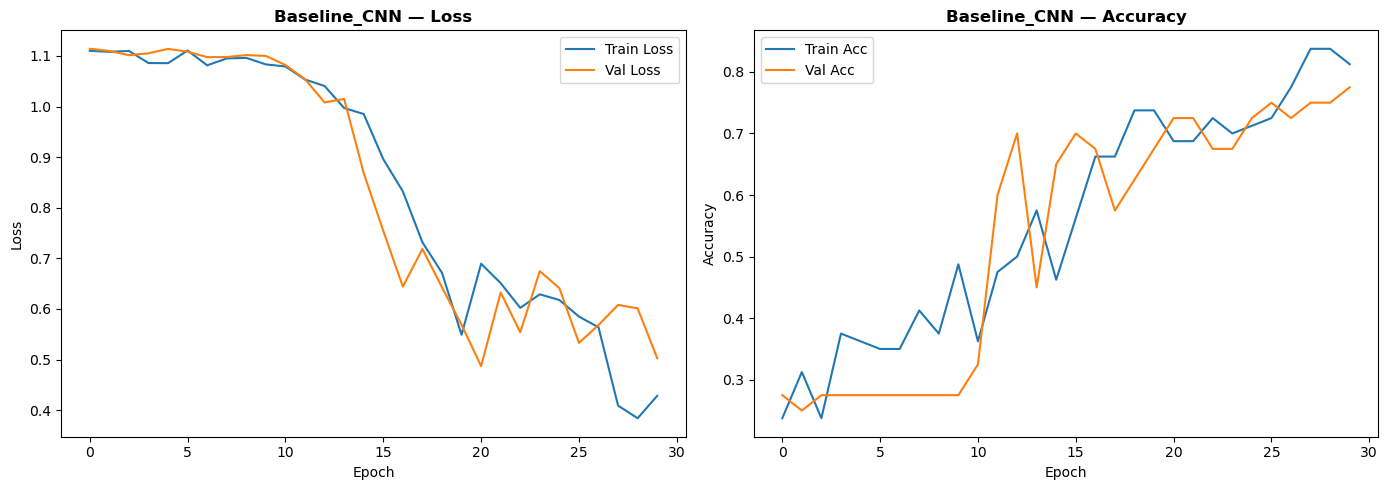


📊 Baseline_CNN
   Test Loss    : 0.5027
   Test Accuracy: 77.50%

Classification Report:
                       precision    recall  f1-score   support

Bacterial leaf blight       0.88      0.94      0.91        16
           Brown spot       0.67      0.62      0.64        13
            Leaf smut       0.73      0.73      0.73        11

             accuracy                           0.78        40
            macro avg       0.76      0.76      0.76        40
         weighted avg       0.77      0.78      0.77        40



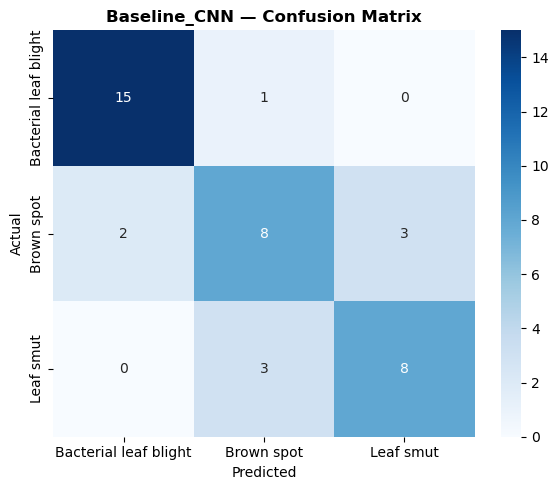

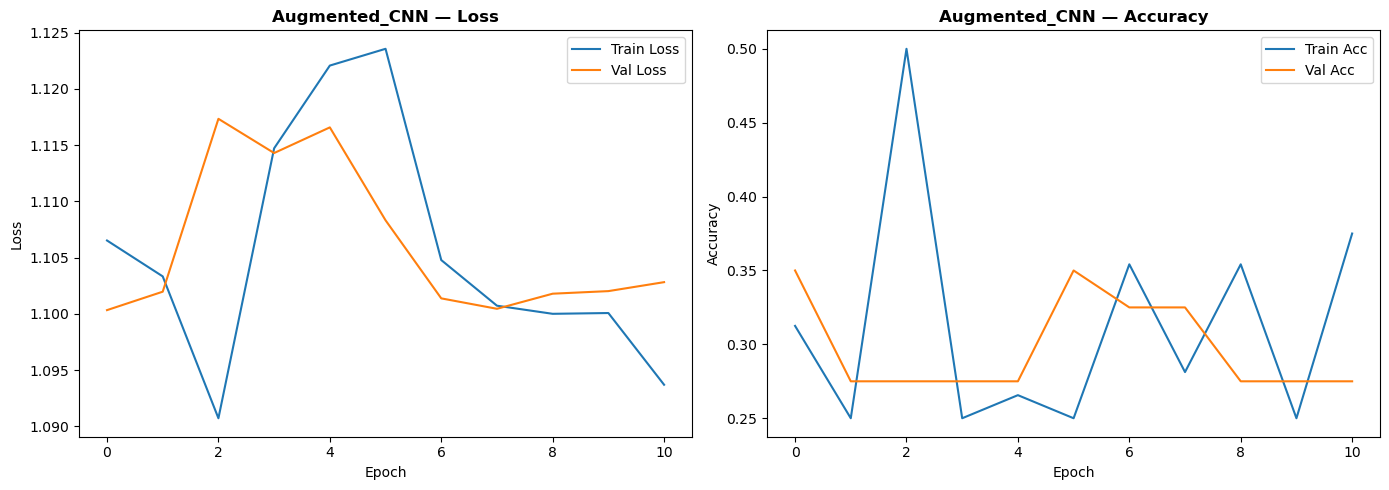


📊 Augmented_CNN
   Test Loss    : 1.1003
   Test Accuracy: 35.00%

Classification Report:
                       precision    recall  f1-score   support

Bacterial leaf blight       0.00      0.00      0.00        16
           Brown spot       0.33      1.00      0.50        13
            Leaf smut       1.00      0.09      0.17        11

             accuracy                           0.35        40
            macro avg       0.44      0.36      0.22        40
         weighted avg       0.38      0.35      0.21        40



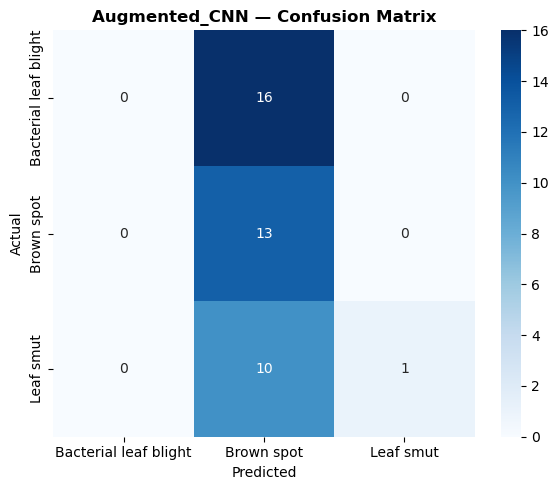

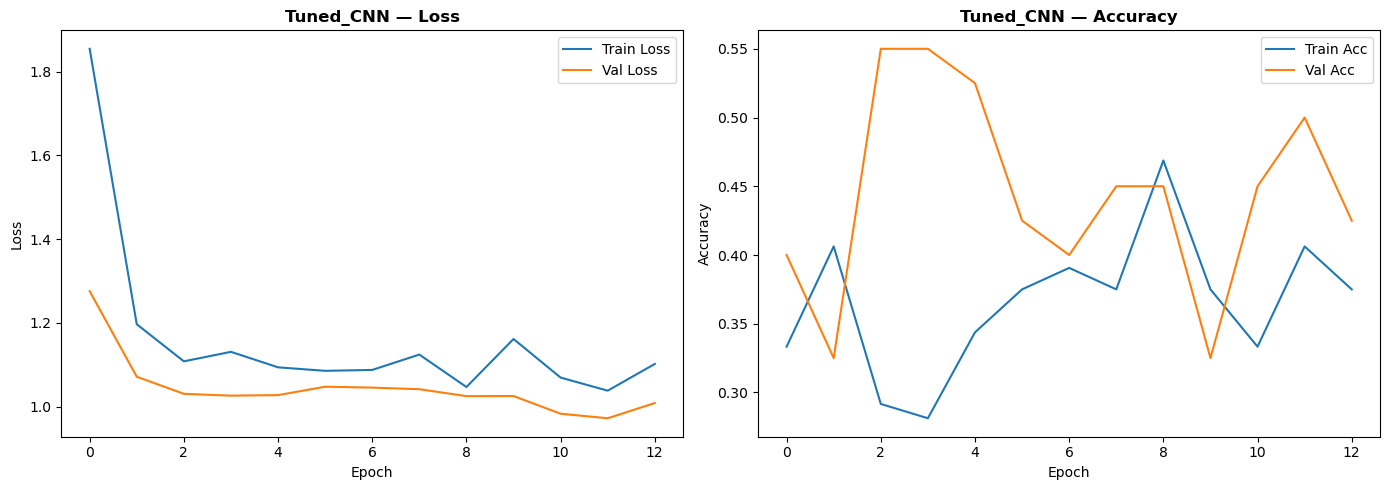


📊 Tuned_CNN
   Test Loss    : 1.0308
   Test Accuracy: 55.00%

Classification Report:
                       precision    recall  f1-score   support

Bacterial leaf blight       0.52      1.00      0.68        16
           Brown spot       0.67      0.46      0.55        13
            Leaf smut       0.00      0.00      0.00        11

             accuracy                           0.55        40
            macro avg       0.39      0.49      0.41        40
         weighted avg       0.42      0.55      0.45        40



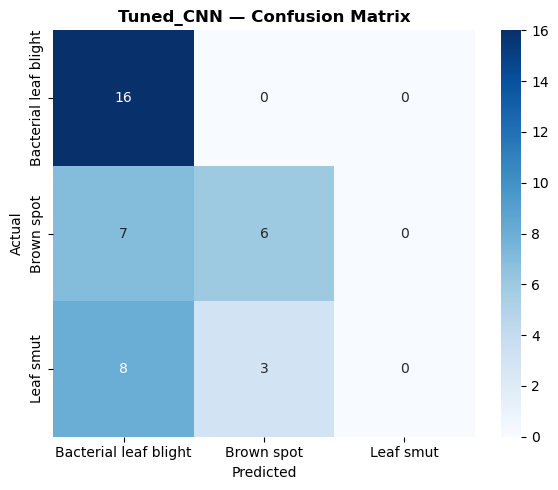

In [19]:
plot_history(history1, 'Baseline_CNN')
acc1 = evaluate_model(model1, X_test, y_test_cat, y_test, class_names, 'Baseline_CNN')

plot_history(history2, 'Augmented_CNN')
acc2 = evaluate_model(model2, X_test, y_test_cat, y_test, class_names, 'Augmented_CNN')

plot_history(history3, 'Tuned_CNN')
acc3 = evaluate_model(model3, X_test, y_test_cat, y_test, class_names, 'Tuned_CNN')

## 12. Model Comparison & Select Best

        Model  Accuracy
 Baseline CNN 77.499998
Augmented CNN 34.999999
    Tuned CNN 55.000001


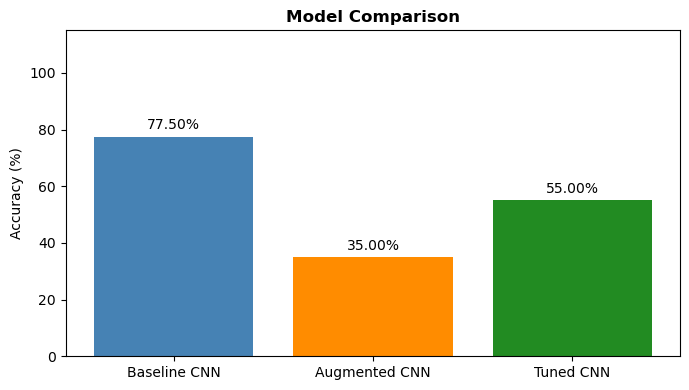


🏆 Best model: Baseline CNN  (77.50%)
✅ Saved to saved_models/best_model.keras


In [20]:
comparison = pd.DataFrame({
    'Model'   : ['Baseline CNN', 'Augmented CNN', 'Tuned CNN'],
    'Accuracy': [acc1*100, acc2*100, acc3*100]
})
print(comparison.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(comparison['Model'], comparison['Accuracy'],
              color=['steelblue', 'darkorange', 'forestgreen'])
ax.bar_label(bars, fmt='%.2f%%', padding=3)
ax.set_ylim(0, 115)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Comparison', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'model_comparison.png'), dpi=120)
plt.show()

# Pick and save the best model
best_idx = np.argmax([acc1, acc2, acc3])
best_model = [model1, model2, model3][best_idx]
best_name  = comparison['Model'].iloc[best_idx]
print(f'\n🏆 Best model: {best_name}  ({comparison["Accuracy"].max():.2f}%)')

best_model.save(os.path.join(MODELS_DIR, 'best_model.keras'))
print(f'✅ Saved to {MODELS_DIR}/best_model.keras')

## 13. Visual Prediction Grid

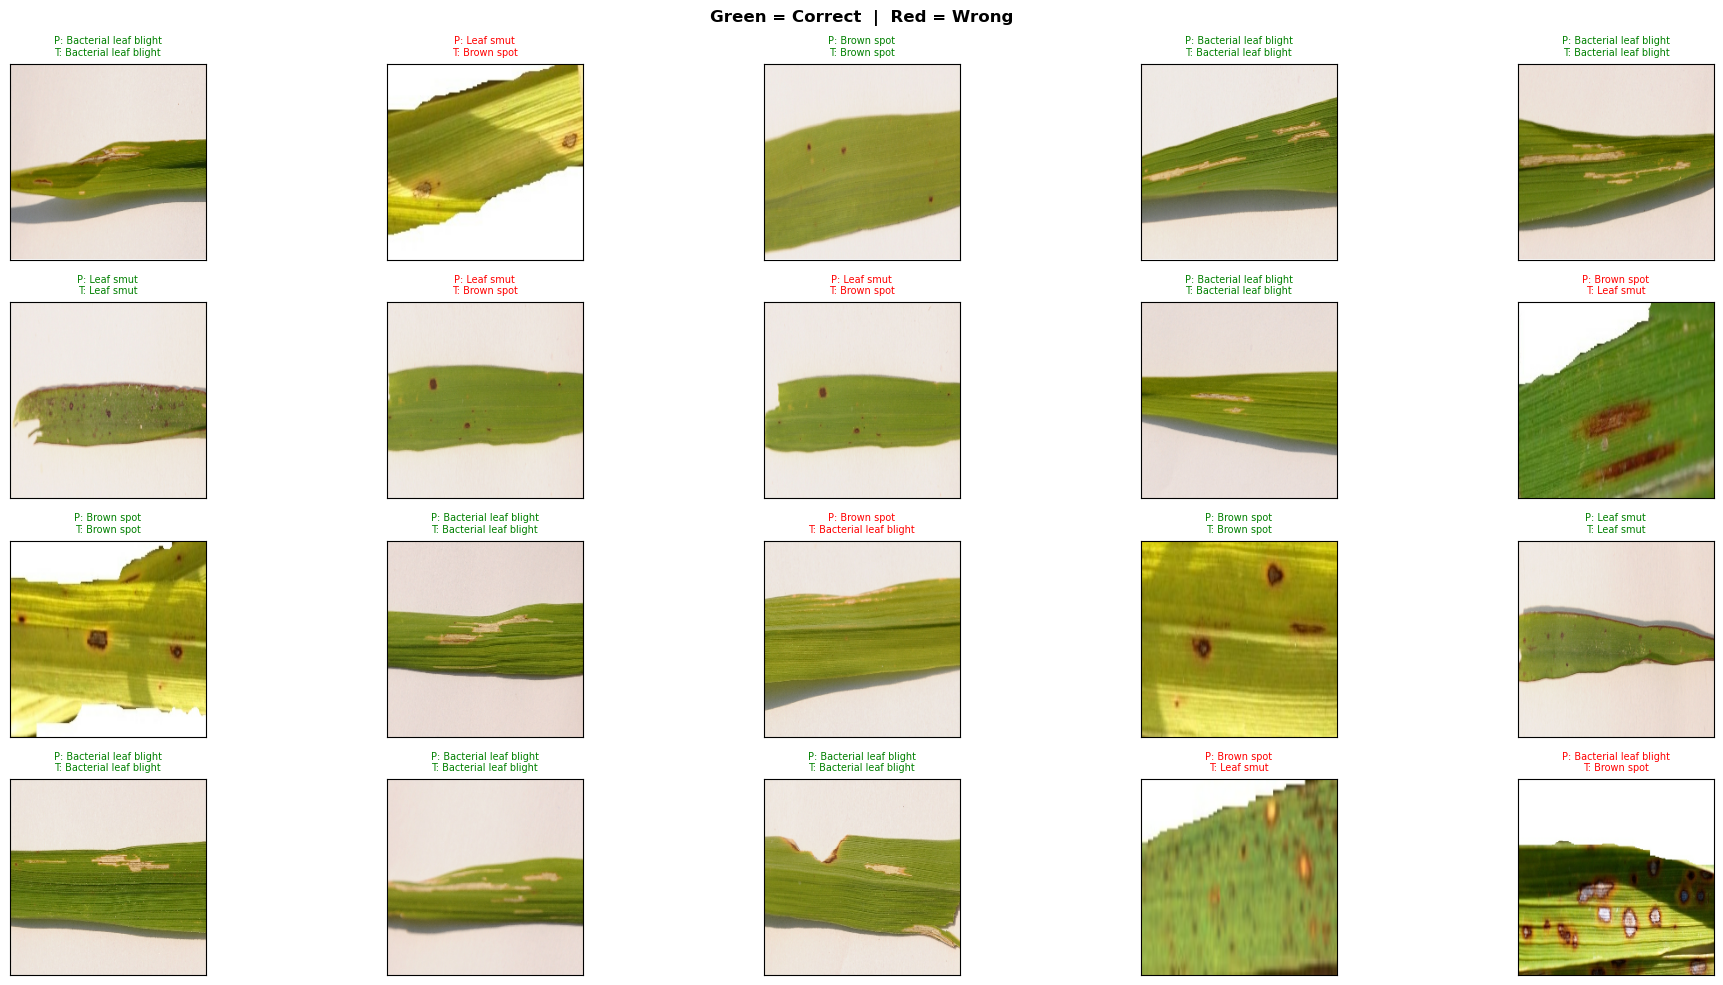

In [21]:
y_pred_all = np.argmax(best_model.predict(X_test, verbose=0), axis=1)

n = min(20, len(X_test))
fig = plt.figure(figsize=(20, 10))
for i, idx in enumerate(np.random.choice(len(X_test), size=n, replace=False)):
    ax = fig.add_subplot(4, 5, i + 1, xticks=[], yticks=[])
    ax.imshow(X_test[idx])
    pred = class_names[y_pred_all[idx]]
    true = class_names[y_test[idx]]
    color = 'green' if pred == true else 'red'
    ax.set_title(f'P: {pred}\nT: {true}', color=color, fontsize=7)
plt.suptitle('Green = Correct  |  Red = Wrong', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 14. Export Model for Streamlit App

In [22]:
# The best_model is already saved as saved_models/best_model.keras
# Copy it to the root directory for the Streamlit app
import shutil
shutil.copy(os.path.join(MODELS_DIR, 'best_model.keras'), 'best_model.keras')
print('✅ Model exported → best_model.keras (ready for app.py)')

✅ Model exported → best_model.keras (ready for app.py)


---
## Summary

| Step | What happened |
|------|---------------|
| Data | 120 rice-leaf images, 3 classes, 224×224 RGB |
| Split | 80 train / 40 test |
| Model 1 | Baseline CNN (5 conv blocks + dense) |
| Model 2 | Same CNN + ImageDataGenerator augmentation |
| Model 3 | Keras Tuner RandomSearch → fine-tuned best params |
| Output | `best_model.keras` ready for Streamlit deployment |

> **Next step:** Run `streamlit run app.py` to launch the web app.